In [1]:
import pandas as pd
import numpy as np
import json

In [21]:
with open("training_history.json", "r") as f:
    data = json.loads(f.read())[0]
data

{'weights': [[1.0, 0.0, 0.0, 0.0],
  [0.0, 1.0, 0.0, 0.0],
  [0.0, 0.0, 1.0, 0.0],
  [0.25, 0.25, 0.20000000298023224, 0.30000001192092896]],
 'epoch': [5.0, 5.0, 5.0, 5.0],
 'bench_resullts': [{'question': {'0': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?",
    '1': 'A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?',
    '2': 'Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?',
    '3': 'James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.  How many total meters does he run a week?',
    '4': "Every day, Wendi feeds each of her chickens thr

In [22]:
data.keys()

dict_keys(['weights', 'epoch', 'bench_resullts', 'loss_history'])

In [23]:
training_instances = len(data['weights'])
training_data = []
for t in range(training_instances):
    training_data.append(
        {
            'w': data['weights'][t],
            'epochs': data['epoch'][t],
            'bench_results': pd.DataFrame(data['bench_resullts'][t]),
            'loss_history': data['loss_history'][t],
        }
    )
training_data[0]

{'w': [1.0, 0.0, 0.0, 0.0],
 'epochs': 5.0,
 'bench_results':                                              question   gold  \
 0   Janet’s ducks lay 16 eggs per day. She eats th...     18   
 1   A robe takes 2 bolts of blue fiber and half th...      3   
 2   Josh decides to try flipping a house.  He buys...  70000   
 3   James decides to run 3 sprints 3 times a week....    540   
 4   Every day, Wendi feeds each of her chickens th...     20   
 5   Kylar went to the store to buy glasses for his...     64   
 6   Toulouse has twice as many sheep as Charleston...    260   
 7   Carla is downloading a 200 GB file. Normally s...    160   
 8   John drives for 3 hours at a speed of 60 mph a...     45   
 9   Eliza's rate per hour for the first 40 hours s...    460   
 10  A new program had 60 downloads in the first mo...    366   
 11  Toula went to the bakery and bought various ty...    694   
 12  Carlos is planting a lemon tree. The tree will...     13   
 13  Melanie is a door-to-doo

In [55]:
imp_columns = [
    "Logical Flow",
    "Structural Organization",
    "Consistency",
    "Factual Correctness",
    "Domain Knowledge Application",
    "Reasoning Validity",
    # "Final Answer Correctness",
    "Strategy Usefulness",
    "Progress Toward Solution",
    "Partial Success Recognition",
    "Error Robustness",
    # "verbosity",
    # "final_comment"
]
final_df = pd.DataFrame()
for t in range(training_instances):
    plotting_data = training_data[t]['bench_results'][imp_columns].mean().to_frame().T
    final_df = pd.concat([final_df, plotting_data], ignore_index=True)


In [56]:
final_df

,Logical Flow,Structural Organization,Consistency,Factual Correctness,Domain Knowledge Application,Reasoning Validity,Strategy Usefulness,Progress Toward Solution,Partial Success Recognition,Error Robustness
0,9.233333,9.516667,9.450000,8.866667,8.916667,8.800000,9.016667,9.133333,9.066667,8.900000
1,9.033333,9.266667,9.050000,8.433333,8.683333,8.383333,8.700000,8.850000,8.800000,8.500000
2,8.916667,9.316667,9.083333,8.433333,8.683333,8.183333,8.800000,8.766667,8.600000,8.200000
3,8.716667,9.366667,9.066667,8.050000,8.450000,7.883333,8.550000,8.450000,8.233333,7.866667


In [82]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


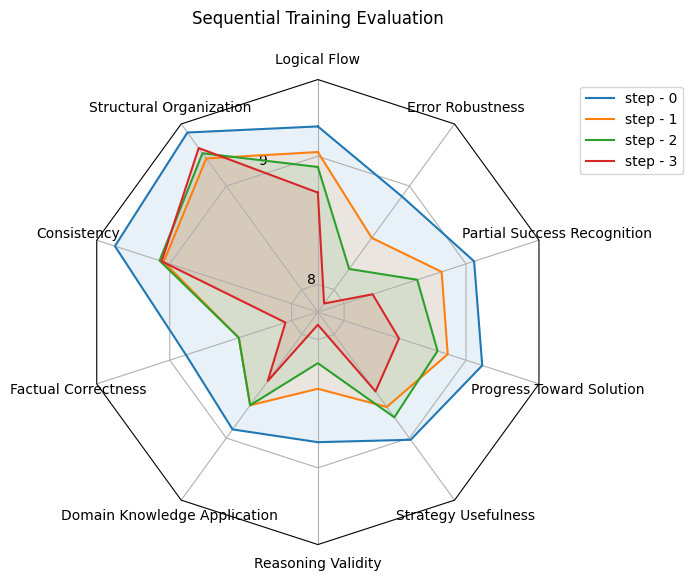

In [84]:

data = [final_df.columns.tolist(),
        ('Sequential Training Evaluation', final_df.values.tolist())]

N = len(data[0])
theta = radar_factory(N, frame='polygon')

spoke_labels = data.pop(0)
title, case_data = data[0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.05)

ax.set_rgrids([1,2,3,4,5,6,7,8,9,10])
ax.set_title(title, ha='center', pad=40)

for i,d in enumerate(case_data):
    line = ax.plot(theta, d, label=f'step - {i}')
    ax.fill(theta, d,  alpha=0.1)
ax.set_varlabels(spoke_labels)

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

In [44]:
plotting_data.values[:2]

array([[10., 10., 10., 10., 10., 10., 10., 10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10., 10., 10.]])